# Prepare a photometric catalog for use with the MSA planner

# Define RUBIES-like selection weights

Weights according to inverse number density in 3D space ``[log(1+z), mag_f444w, f150w_f444w]``.

See [de Graaff et al. 2025](https://ui.adsabs.harvard.edu/abs/2025A%26A...697A.189D/abstract) for more information on the mask design and target priorities / weights.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree, ConvexHull

from grizli import utils


## Define reference KDTree

In [2]:
ref = utils.read_catalog("../data/reference_catalog.fits")
ref.info()

<GTable length=257890>
     name      dtype  unit               description                   class    
------------- ------- ---- ---------------------------------------- ------------
           id   int64                                               MaskedColumn
           ra float64  deg                                                Column
          dec float64  deg                                                Column
       z_phot float32                                                     Column
      f_f150w float32  uJy                     Flux in NIRCam F150W       Column
      f_f444w float32  uJy                     Flux in NIRCam F444W       Column
red_selection    bool      red selection as a function of z and mag       Column


In [3]:
label_names = ['log(1+z)','m444','150-444']
label_names = ['z','m444','150-444']

label_ranges = [(0, np.log(1+10)), (19, 27), (-0.5, 5)]
# label_ranges = [(0, np.log(1+10)), (18, 27.5), (-1.0, 6)]
label_ranges = [(0, np.log(1+10.5)), (18, 28.5), (-1.5, 6)]

In [4]:
labels = np.array([
    np.log(1 + ref['z_phot']),
    23.9 - 2.5*np.log10(ref['f_f444w']),
    -2.5*np.log10(ref['f_f150w'] / ref['f_f444w']),
]).T

# Normalize label space based on the red selection
lmi = np.nanpercentile(labels[ref['red_selection']], 0.1, axis=0)
lma = np.nanpercentile(labels[ref['red_selection']], 99.9, axis=0)

for i, param in enumerate(label_names):
    print(f'{param:>12} {lmi[i]:>6.2f} - {lma[i]:>6.2f}')

lnorm = (labels-lmi)/(lma-lmi)
lnorm[~np.isfinite(lnorm)] = -1e10

tr = cKDTree(lnorm)
dk = np.array([tr.query(ln, k=8)[0][-1] for ln in lnorm])

klimits = np.percentile(dk, [5,95])
weight = np.log(np.clip(dk, *klimits)**3)

klimits

           z   0.70 -   2.91
        m444  19.28 -  26.92
     150-444   0.54 -   5.73


array([0.0067315 , 0.03579315])

In [5]:
from scipy.spatial import ConvexHull

hulls = {}
red_hulls = {}

for i in range(2):
    for j in range(i+1,3):
        coo = labels[:,[i,j]]
        ok = np.isfinite(coo).sum(axis=1) == 2
        hull = ConvexHull(coo[ok])
        hulls[(i,j)] = coo[ok][hull.vertices,:]
        hulls[(j,i)] = coo[ok][hull.vertices,::-1]

        ok &= ref['red_selection']
        hull = ConvexHull(coo[ok])
        red_hulls[(i,j)] = coo[ok][hull.vertices,:]
        red_hulls[(j,i)] = coo[ok][hull.vertices,::-1]


## Show reference weights

In [6]:
xlabels = labels
xweight = weight

in_red = ref['red_selection'] & True


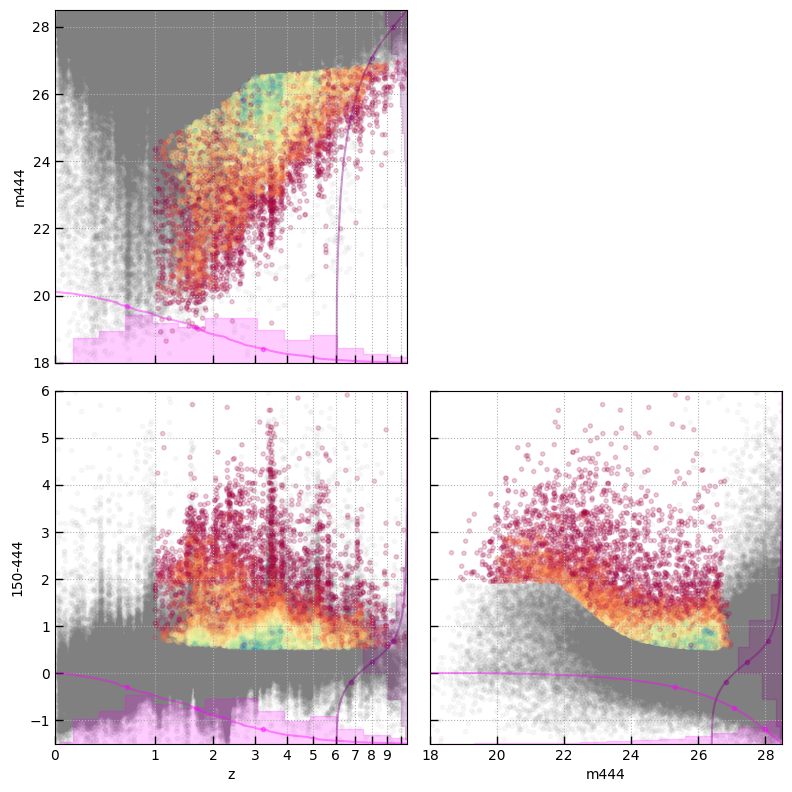

In [7]:
fig, axes = plt.subplots(2,2,figsize=(8,8))

xsubset = np.isfinite(xlabels).sum(axis=1) == 3

for i in range(3):
    lr = label_ranges[i]
    xsubset &= (xlabels[:,i] > lr[0]) & (xlabels[:,i] < lr[1])

N = xsubset.sum()

for arow, i in enumerate([0,1]):
    for acol, j in enumerate(range(i+1, 3)[::1]):
        ax = axes[arow-acol, arow]

        ax.scatter(
            xlabels[:,i][xsubset & in_red],
            xlabels[:,j][xsubset & in_red],
            c=xweight[xsubset & in_red],
            cmap='Spectral_r',
            alpha=0.2,
        )

        ax.scatter(
            xlabels[:,i][xsubset & ~in_red],
            xlabels[:,j][xsubset & ~in_red],
            color='0.5', zorder=-10,
            alpha=0.05,
        )

        if 'z' in label_names[i]:
            xt = [0,1,2,3,4,5,6,7,8,9,10]
            ax.set_xticks(np.log(1+np.array(xt)))
            xt[-1] = ''
        else:
            xt = None
        
        if (acol-arow) in (1, -1):
            ax.set_xlabel(label_names[i])
            if xt is not None:
                ax.set_xticklabels(xt)
        else:
            ax.set_xticklabels([])
            
        if arow == 0:
            ax.set_ylabel(label_names[j])
        else:
            ax.set_yticklabels([])

        NBIN = 16
        dl = label_ranges[i][1] - label_ranges[i][0]
        bins = np.linspace(label_ranges[i][0] - dl/NBIN, label_ranges[i][1] + dl/NBIN, NBIN)

        xh = np.histogram(xlabels[:,i], bins=bins, density=True)
        dy = label_ranges[j][1] - label_ranges[j][0]
        ax.fill_between(
            xh[1][:-1] + np.diff(xh[1]),
            xh[0]*0 + label_ranges[j][0],
            xh[0]*0.2*dy + label_ranges[j][0],
            step='mid', color='magenta', alpha=0.2
        )

        xso = np.argsort(xlabels[:,i][xsubset])
        yso = label_ranges[j][0] + (1-np.arange(N)/N)*0.2*dy
        iq = (np.array([0.2, 0.5, 0.8]) * N).astype(int)
        
        pl = ax.plot(xlabels[:,i][xsubset][xso], yso, color='magenta', alpha=0.4)
        ax.scatter(xlabels[:,i][xsubset][xso][iq], yso[iq], color=pl[0].get_color(), alpha=0.4)
        
        dl = label_ranges[j][1] - label_ranges[j][0]
        bins = np.linspace(label_ranges[j][0] - dl/NBIN, label_ranges[j][1] + dl/NBIN, NBIN)
        
        xh = np.histogram(xlabels[:,j], bins=bins, density=True)
        dy = label_ranges[i][1] - label_ranges[i][0]
        ax.fill_betweenx(
            xh[1][:-1] + np.diff(xh[1]),
            label_ranges[i][1] - xh[0]*0,
            label_ranges[i][1] - xh[0]*0.2*dy,
            step='mid', color='purple', alpha=0.2
        )

        xso = np.argsort(xlabels[:,j][xsubset])
        yso = label_ranges[i][1] - (1-np.arange(N)/N)*0.2*dy
        pl = ax.plot(yso, xlabels[:,j][xsubset][xso], color='purple', alpha=0.4)
        ax.scatter(yso[iq], xlabels[:,j][xsubset][xso][iq], color=pl[0].get_color(), alpha=0.4)


        ax.set_xlim(label_ranges[i])            
        ax.set_ylim(label_ranges[j])
        ax.grid()
        
axes[0,1].axis('off')
fig.tight_layout(pad=1)
# fig.savefig('/tmp/prism_selection_photometry.png')


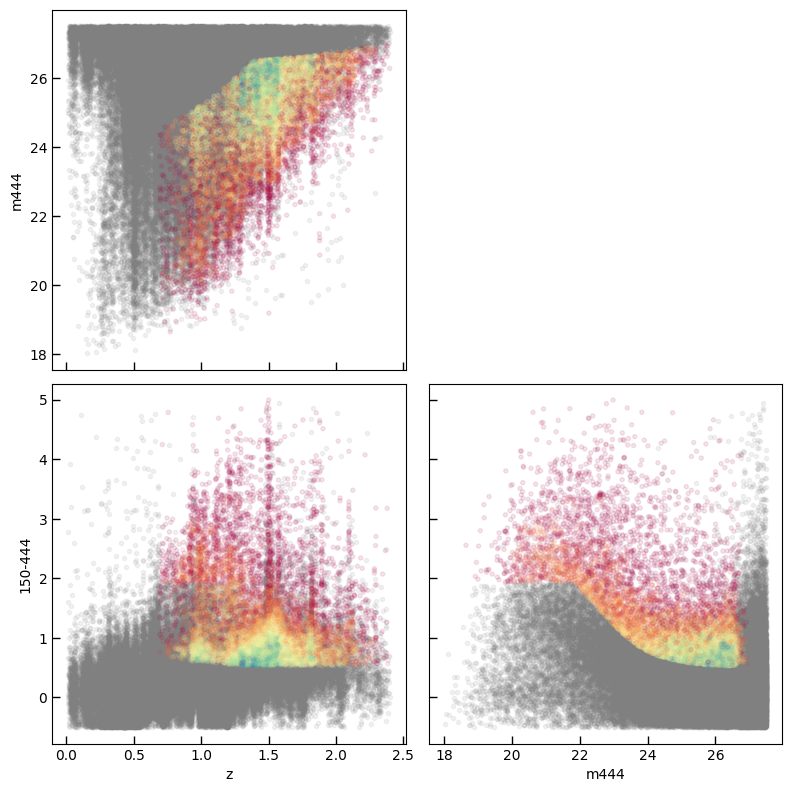

In [8]:
fig, axes = plt.subplots(2,2,figsize=(8,8))

label_ranges = [(0, np.log(1+10)), (18, 27.5), (-0.5, 5)]

# Faint
# label_ranges = [(0, np.log(1+10.5)), (18, 28.5), (-1.5, 6)]

subset = ref['ra'] > 0
for i in range(3):
    lr = label_ranges[i]
    subset &= (labels[:,i] > lr[0]) & (labels[:,i] < lr[1])

is_red = ref['red_selection']

for arow, i in enumerate([0,1]):
    for acol, j in enumerate(range(i+1, 3)[::1]):
        ax = axes[arow-acol, arow]

        ax.scatter(
            labels[:,i][subset & is_red],
            labels[:,j][subset & is_red],
            c=weight[subset & is_red],
            cmap='Spectral_r',
            alpha=0.1,
        )

        ax.scatter(
            labels[:,i][subset & ~is_red],
            labels[:,j][subset & ~is_red],
            color='0.5', zorder=-10,
            alpha=0.1,
        )

        if (acol-arow) in (1, -1):
            ax.set_xlabel(label_names[i])
        else:
            ax.set_xticklabels([])
            
        if arow == 0:
            ax.set_ylabel(label_names[j])
        else:
            ax.set_yticklabels([])

axes[0,1].axis('off')
fig.tight_layout(pad=1)

# Initialize MSA catalog

In [9]:
# effective aperture corrections for simple DJA/grizli catalogs, which aren't PSF matched but are just 
# simple apertures

zp = {
 'f1000w_tot_1': 1.88995,
 'f105w_tot_1': 0.928812,
 'f115w_tot_1': 0.866251,
 'f125w_tot_1': 0.943637,
 'f1280w_tot_1': 2.376018,
 'f140w_tot_1': 0.960043,
 'f1500w_tot_1': 3.20918,
 'f150w_tot_1': 0.861518,
 'f160w_tot_1': 0.973751,
 'f1800w_tot_1': 3.842774,
 'f182m_tot_1': 0.90068,
 'f200w_tot_1': 0.897878,
 'f2100w_tot_1': 4.783979,
 'f210m_tot_1': 0.920488,
 'f277w_tot_1': 1.0,
 'f356w_tot_1': 1.079638,
 'f410m_tot_1': 1.119493,
 'f435w_tot_1': 1.056324,
 'f444w_tot_1': 1.157503,
 'f560w_tot_1': 1.336112,
 'f606w_tot_1': 0.903465,
 'f606wu_tot_1': 0.905366,
 'f770w_tot_1': 1.585876,
 'f814w_tot_1': 0.848567
}

In [10]:
! find VENUS/*

VENUS/PG004
VENUS/PG004/pg004_phot_apcorr.fits
VENUS/PG004/go12581_v1.aptx
VENUS/PG004/pg004_wht_fill.json
VENUS/PG004/go12581_v1.aptx.2026_06_02_07_29.aptbackup
VENUS/PG004/go12581_v1.aptx.2026_05_29_16_21.aptbackup
VENUS/PG004/go12581_v1.aptx.2026_06_01_21_28.aptbackup
VENUS/PG004/go12581_v1.aptx.2026_06_01_19_38.aptbackup
VENUS/PG004/go12581_v1.aptx.2026_06_01_22_01.aptbackup
VENUS/PG004/pg004.eazypy.zout.fits
VENUS/PG004/go12581_v1.aptx.2026_05_29_16_27.aptbackup
VENUS/PG004/go12581_v1.aptx.2026_06_01_21_32.aptbackup
VENUS/PG004/PG004-targets.csv
VENUS/PG004/12581-obs1-1-TA.csv
VENUS/PG004/go12581_v1.aptx.2026_06_03_21_40.aptbackup
VENUS/PG004/pg004_v1_260529.vot
VENUS/PG004/12581-obs1-exp1-c1e1-PRISM-CLEAR.csv
VENUS/PG004/go12581_v1.aptx.2026_06_03_21_41.aptbackup
VENUS/PG004_eazy_v0.2.zip


In [11]:
zout = utils.read_catalog("VENUS/PG004/pg004.eazypy.zout.fits")
cat = utils.read_catalog("VENUS/PG004/pg004_phot_apcorr.fits")

prefix = "VENUS/PG004/pg004"

zout['F444W'] = 23.9 - 2.5 * np.log10(cat['f444w_tot_1'] * zp['f444w_tot_1'])

/var/folders/dw/fyp140x977s3y5d2mdxw6m0w0000gn/T/ipykernel_87005/1168517663.py:6: RuntimeWarning: invalid value encountered in log10
  zout['F444W'] = 23.9 - 2.5 * np.log10(cat['f444w_tot_1'] * zp['f444w_tot_1'])


# Evaluate weights on the target catalog

For example, the DJA catalogs at https://s3.amazonaws.com/grizli-v2/JwstMosaics/v7/index.html.

The absolute value of the weights doesn't matter so much, most important is the *sorting*.

In [12]:

xlabels = np.array([
    np.log(1 + zout['z_phot']),
    23.9 - 2.5*np.log10(cat['f444w_tot_1'] * zp['f150w_tot_1']),
    -2.5*np.log10(cat['f150w_tot_1'] * zp['f150w_tot_1'] / (cat['f444w_tot_1'] * zp['f444w_tot_1']))
]).T

xlnorm = (xlabels-lmi)/(lma-lmi)
xlnorm[~np.isfinite(xlnorm)] = -1e10

xdk = np.array([tr.query(ln, k=8)[0][-1] for ln in xlnorm])

xweight = np.log(np.clip(xdk, *klimits)**3)

in_red = np.isfinite(xdk)
for i in range(2):
    for j in range(i+1,3):
        coo = xlabels[:,[i,j]]
        hull = utils.SRegion(red_hulls[(i,j)])
        in_red &= hull.path[0].contains_points(coo)

zout['weight'] = xweight
zout['red'] = in_red

/var/folders/dw/fyp140x977s3y5d2mdxw6m0w0000gn/T/ipykernel_87005/4281989083.py:2: RuntimeWarning: divide by zero encountered in log
  np.log(1 + zout['z_phot']),
/var/folders/dw/fyp140x977s3y5d2mdxw6m0w0000gn/T/ipykernel_87005/4281989083.py:3: RuntimeWarning: invalid value encountered in log10
  23.9 - 2.5*np.log10(cat['f444w_tot_1'] * zp['f150w_tot_1']),
/var/folders/dw/fyp140x977s3y5d2mdxw6m0w0000gn/T/ipykernel_87005/4281989083.py:4: RuntimeWarning: invalid value encountered in log10
  -2.5*np.log10(cat['f150w_tot_1'] * zp['f150w_tot_1'] / (cat['f444w_tot_1'] * zp['f444w_tot_1']))


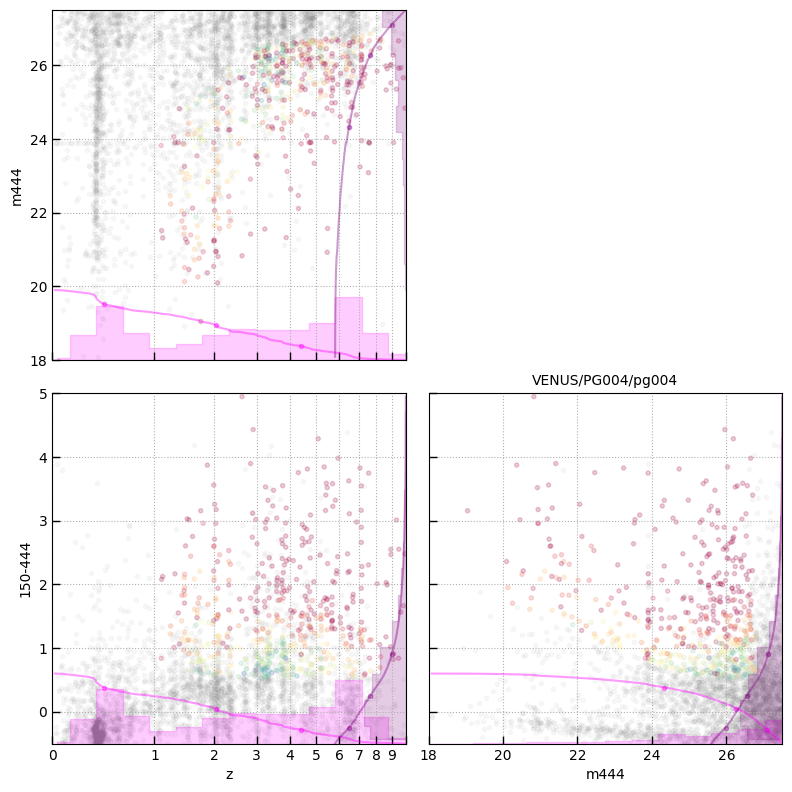

In [13]:
fig, axes = plt.subplots(2,2,figsize=(8,8))

xsubset = np.isfinite(xlabels).sum(axis=1) == 3

for i in range(3):
    lr = label_ranges[i]
    xsubset &= (xlabels[:,i] > lr[0]) & (xlabels[:,i] < lr[1])

N = xsubset.sum()

for arow, i in enumerate([0,1]):
    for acol, j in enumerate(range(i+1, 3)[::1]):
        ax = axes[arow-acol, arow]

        ax.scatter(
            xlabels[:,i][xsubset & in_red],
            xlabels[:,j][xsubset & in_red],
            c=xweight[xsubset & in_red],
            cmap='Spectral_r',
            alpha=0.2,
        )

        ax.scatter(
            xlabels[:,i][xsubset & ~in_red],
            xlabels[:,j][xsubset & ~in_red],
            color='0.5', zorder=-10,
            alpha=0.05,
        )

        if 'z' in label_names[i]:
            xt = [0,1,2,3,4,5,6,7,8,9,10]
            ax.set_xticks(np.log(1+np.array(xt)))
            xt[-1] = ''
        else:
            xt = None
        
        if (acol-arow) in (1, -1):
            ax.set_xlabel(label_names[i])
            if xt is not None:
                ax.set_xticklabels(xt)
        else:
            ax.set_xticklabels([])
            
        if arow == 0:
            ax.set_ylabel(label_names[j])
        else:
            ax.set_yticklabels([])

        NBIN = 16
        dl = label_ranges[i][1] - label_ranges[i][0]
        bins = np.linspace(label_ranges[i][0] - dl/NBIN, label_ranges[i][1] + dl/NBIN, NBIN)

        xh = np.histogram(xlabels[:,i], bins=bins, density=True)
        dy = label_ranges[j][1] - label_ranges[j][0]
        ax.fill_between(
            xh[1][:-1] + np.diff(xh[1]),
            xh[0]*0 + label_ranges[j][0],
            xh[0]*0.2*dy + label_ranges[j][0],
            step='mid', color='magenta', alpha=0.2
        )

        xso = np.argsort(xlabels[:,i][xsubset])
        yso = label_ranges[j][0] + (1-np.arange(N)/N)*0.2*dy
        iq = (np.array([0.2, 0.5, 0.8]) * N).astype(int)
        
        pl = ax.plot(xlabels[:,i][xsubset][xso], yso, color='magenta', alpha=0.4)
        ax.scatter(xlabels[:,i][xsubset][xso][iq], yso[iq], color=pl[0].get_color(), alpha=0.4)
        
        dl = label_ranges[j][1] - label_ranges[j][0]
        bins = np.linspace(label_ranges[j][0] - dl/NBIN, label_ranges[j][1] + dl/NBIN, NBIN)
        
        xh = np.histogram(xlabels[:,j], bins=bins, density=True)
        dy = label_ranges[i][1] - label_ranges[i][0]
        ax.fill_betweenx(
            xh[1][:-1] + np.diff(xh[1]),
            label_ranges[i][1] - xh[0]*0,
            label_ranges[i][1] - xh[0]*0.2*dy,
            step='mid', color='purple', alpha=0.2
        )

        xso = np.argsort(xlabels[:,j][xsubset])
        yso = label_ranges[i][1] - (1-np.arange(N)/N)*0.2*dy
        pl = ax.plot(yso, xlabels[:,j][xsubset][xso], color='purple', alpha=0.4)
        ax.scatter(yso[iq], xlabels[:,j][xsubset][xso][iq], color=pl[0].get_color(), alpha=0.4)


        ax.set_xlim(label_ranges[i])            
        ax.set_ylim(label_ranges[j])
        ax.grid()

axes[1,1].set_title(prefix)

axes[0,1].axis('off')
fig.tight_layout(pad=1)

# TA Reference sources

To first order, the NIRSpec TA filter F110W is very similar to NIRCam F115W.  Make columns needed for NRS TA filled with F115W magnitudes.

The sources indicated as potential `Reference` sources should be checked carefully!
  - Magnitudes reasonable
  - Not saturated in the detection band, or anything else that would compromise their catalogued coordinates
  - Reasonably isolated (i.e., the brightest source within ~few arcsec)
  - Compact galaxies can be OK

In [14]:
mag_f115w = 23.9 - 2.5 * np.log10(cat['f115w_tot_1'] * zp['f115w_tot_1'])
sn_f115w = cat['f115w_tot_1'] / cat['f115w_etot_1']

/var/folders/dw/fyp140x977s3y5d2mdxw6m0w0000gn/T/ipykernel_87005/1701332574.py:1: RuntimeWarning: invalid value encountered in log10
  mag_f115w = 23.9 - 2.5 * np.log10(cat['f115w_tot_1'] * zp['f115w_tot_1'])


In [15]:
ta = utils.GTable()

ta['Ellipticity'] = 1.0 - cat['b_image'] / cat['a_image']
ta['Ellipticity'].format = '.2f'

try:
    ta['R50'] =  cat['flux_radius'].filled(-1)
except:
    ta['R50'] =  cat['flux_radius']

ta['NRS_F110W'] = mag_f115w
ta['NRS_F110W'][~np.isfinite(ta['NRS_F110W'])] = 99

ta['NRS_F140X'] = 99
ta['NRS_CLEAR'] = 99
    
ta['NRS_F110W'].format = '.2f'
ta['NRS_F140X'].format = '.2f'
ta['NRS_CLEAR'].format = '.2f'


In [16]:
## Compact source selection
stars = (ta["R50"] > 2) & (ta["R50"] < 3)
stars &= ta['Ellipticity'] < 0.1
stars &= sn_f115w > 20
stars &= (ta['NRS_F110W'] > 18) & (ta['NRS_F110W'] < 25.7)

# masked pixels within aperture are probably saturated
stars &= cat['f115w_mask_aper_1'] == 0
stars.sum()

1556

(17.0, 27.0)

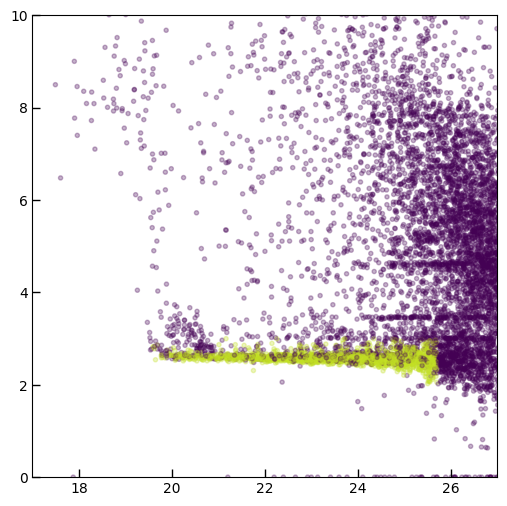

In [17]:
plt.scatter(ta['NRS_F110W'], ta["R50"], c=stars, vmax=1.1, alpha=0.3)

plt.ylim(0, 10)
plt.xlim(17, 27)

## Isolation criteria

Only use sources that don't have bright neighbors within ~2"

In [18]:
from scipy.spatial import cKDTree
from tqdm import tqdm

coo = np.array([cat["ra"], cat["dec"]]).T
cosd = np.array([np.cos(np.median(cat["dec"])/180*np.pi), 1.0])
coo = (coo - np.median(coo, axis=0)) * cosd * 3600.

tree = cKDTree(coo)

In [19]:
nn_list = tree.query_ball_tree(tree, 2.0)

In [20]:
nn_count = np.zeros(len(cat))

dmag_threshold = 0.5 # neighbors brighter than mag_i  + dmag_threshold
for i, nn in tqdm(enumerate(nn_list)):
    dmag = ta['NRS_F110W'][nn] - ta['NRS_F110W'][i]
    nn_count[i] = (dmag < dmag_threshold).sum() - 1

is_iso = nn_count == 0

11699it [00:00, 46016.13it/s]


In [21]:
print(f"Total stars, N = {stars.sum()}")
print(f"Isolated stars, N = {(stars & is_iso).sum()}")

ta["Reference"] = (stars & is_iso) * 1
ta

Total stars, N = 1556
Isolated stars, N = 853


Ellipticity,R50,NRS_F110W,NRS_F140X,NRS_CLEAR,Reference
,,uJy,,,
float64,float64,float64,int64,int64,int64
0.03,0.0,30.51,99.00,99.00,0
0.18,0.5382724520324231,30.16,99.00,99.00,0
0.07,2.588352526586479,22.50,99.00,99.00,0
0.03,2.3676482024616448,25.44,99.00,99.00,0
0.50,7.035807284615698,24.50,99.00,99.00,0
0.55,6.997473508296797,28.60,99.00,99.00,0
0.42,8.206873046447052,24.59,99.00,99.00,0
0.52,7.006009214757325,26.77,99.00,99.00,0


In [22]:
nrs = utils.GTable()

nrs['ID']  = zout['id']
nrs['RA']  = zout['ra']
nrs['Dec'] = zout['dec']

try:
    nrs['Magnitude'] = zout['F444W'].filled(40)
    nrs['Redshift'] =  zout['z_phot'].filled(-1)
except:
    nrs['Magnitude'] = zout['F444W']
    nrs['Redshift'] =  zout['z_phot']
    nrs['Magnitude'][~np.isfinite(zout['F444W'])] = 50
    nrs['Redshift'][~np.isfinite(nrs['Redshift'])] = 30

# nrs['Weight'] =    zuse['xweight']
# nrs['Priority'] =  zuse['priority']

nrs['Ellipticity'] = 1.0 - cat['b_image'] / cat['a_image']
nrs['Ellipticity'].format = '.2f'

# try:
#     nrs['Stellarity'] =  zout['stellarity'].filled(0)
# except AttributeError:
#     nrs['Stellarity'] =  zout['stellarity']
    
try:
    nrs['R50'] =  cat['flux_radius'].filled(-1)
except:
    nrs['R50'] =  cat['flux_radius']
    
nrs['R50'].format = '.2f'

nrs['Magnitude'].format = '.3f'
try:
    nrs['Magnitude'] = nrs['Magnitude'].filled(99)
except:
    pass
    
nrs['Redshift'].format = '.4f'
nrs['RA'].format = '.7f'
nrs['Dec'].format = '.7f'

for c in ta.colnames:
    nrs[c] = ta[c]

nrs

ID,RA,Dec,Magnitude,Redshift,Ellipticity,R50,NRS_F110W,NRS_F140X,NRS_CLEAR,Reference
,deg,deg,uJy,,,,uJy,,,
int32,float64,float64,float64,float32,float64,float64,float64,int64,int64,int64
1,289.2505037,-33.5452845,99.000,-1.0000,0.03,0.0,30.51,99.00,99.00,0
2,289.2524870,-33.5450885,99.000,1.2989,0.18,0.5382724520324231,30.16,99.00,99.00,0
3,289.2504920,-33.5450635,23.593,6.3323,0.07,2.588352526586479,22.50,99.00,99.00,0
4,289.2507441,-33.5448939,26.513,6.2054,0.03,2.3676482024616448,25.44,99.00,99.00,0
5,289.2542902,-33.5448019,25.760,6.1787,0.50,7.035807284615698,24.50,99.00,99.00,0
6,289.2534218,-33.5447407,26.137,4.7680,0.55,6.997473508296797,28.60,99.00,99.00,0
7,289.2531409,-33.5448280,23.605,1.4195,0.42,8.206873046447052,24.59,99.00,99.00,0
8,289.2533440,-33.5447007,26.500,6.7926,0.52,7.006009214757325,26.77,99.00,99.00,0


# Target priorities

In [23]:
pvals = utils.read_catalog("VENUS/PG004/PG004-targets.csv")
pvals

priority,label,ra,dec,original_ra,original_dec,z,mag,mag_band,object_type,magnification,uploader,description
str2,str14,float64,float64,int64,int64,int64,int64,int64,str22,float64,str21,str72
P0,PG004-x-P0,289.258777,-33.525674,--,--,--,--,--,"LRD, high-mu",12.58,auto-from-grade-sheet,"One LRD in Hiroto's 'red eyes', with larger magnification"
P0,PG004-x-P0-#24,289.258762,-33.525608,--,--,--,--,--,LRD,12.9,auto-from-grade-sheet,Red eyes. Another LRD in the same galaxy with above one
P1,PG004-1037-P1,289.280574,-33.535021,--,--,--,--,--,SFG,24.67,yourname,Risky high-z candidate at z~17.
P1,PG004-2643-P1,289.2887171800844,-33.5266428066435,--,--,--,--,--,very bright QG at z~4,17.61,Seiji,and high-mu mu~20
P1,PG004-3060-P1,289.289574,-33.524092,--,--,--,--,--,Einstein ring galaxies,14.06,Tomokazu Kiyota,"F444W=20.8 mag (very bright in G395M wavelength), Einstein ring."
P1,PG004-3219-P1,289.26899302410715,-33.52756488657821,--,--,--,--,--,Bright and high-mu,224.32,Tomokazu Kiyota,F444W bright (=23.48) and high mu (~200)
P1,PG004-7233-P1,289.2794510218595,-33.48665119121184,--,--,--,--,--,SFG,--,yourname,Moderately magnified z~12 candidate.
P1,PG004-8101-P1,289.24733647214396,-33.48100908181474,--,--,--,--,--,LRD,--,yourname,z~8.6 LRD
P1,PG004-8732-P1,289.259864,-33.477031,--,--,--,--,--,Very red galaxy,--,Tomokazu Kiyota,Very red (F090W-F444W>5) and F444W bright (=21.25mag). DSFG? QG?


In [24]:
idx, dr, dx, dy = cat.match_to_catalog_sky(pvals, get_2d_offset=True)
has_match = dr.value < 0.1

zout['priority'] = 9
for i in range(3):
    zout['priority'][idx[has_match & (pvals['priority'] == f'P{i}')]] = i

utils.Unique(zout['priority'])

   N  value     
====  ==========
   2           0
  11           1
11686           9


In [25]:
highz_mag = 26.5
lowz_mag = 25

highz_bright = zout['F444W'] < highz_mag
lowz_bright = zout['F444W'] < lowz_mag

dmdz=2.; m0=25.8
mlim = dmdz*np.log10((1+zout['z_phot'])/2.5) + m0

magz = [0, 1, 3.4, 6, 8, 12, 18]
magz_lim = [24.5, 24.5, 26.5, 27, 27.1, 27.5, 27.5]

mlim = np.interp(zout['z_phot'], magz, magz_lim)

highz_bright = lowz_bright = zout['F444W'] < mlim

priorities = {
    0: "Must get",
    1: "Desirable",
    2: "If possible",
    3: 'placeholder',
    4: f'{highz_mag:.1f} bright highz z > 3.4',
    6:  'faint highz z > 3.4',
    8: f'{lowz_mag:.1f} bright lowz  z < 3.4 ',
    10: 'faint lowz  z < 3.4',
    12: 'likely star',
    13: 'p > 2, something other than above',
    16: 'saturated, few filters, flux_radius < 1',
}

priorities

/var/folders/dw/fyp140x977s3y5d2mdxw6m0w0000gn/T/ipykernel_87005/715152079.py:8: RuntimeWarning: divide by zero encountered in log10
  mlim = dmdz*np.log10((1+zout['z_phot'])/2.5) + m0


{0: 'Must get',
 1: 'Desirable',
 2: 'If possible',
 3: 'placeholder',
 4: '26.5 bright highz z > 3.4',
 6: 'faint highz z > 3.4',
 8: '25.0 bright lowz  z < 3.4 ',
 10: 'faint lowz  z < 3.4',
 12: 'likely star',
 13: 'p > 2, something other than above',
 16: 'saturated, few filters, flux_radius < 1'}

In [26]:
# Rework priorities
p3 = zout['priority'] > 2.8

zmax = (zout['z_phot'] > 0.7) & (zout['z_phot'] < 14) & (zout['F444W'] < 28.5)

# bad &= (zout['priority'] > 2)

# Take out "red" test
zout['test_red'] = zout['ra'] > 0

zout['priority'][p3] = 13

zcut = 3.3 # Used for rubies, limit of useful lines in G395M

# highz
zout['priority'][p3 &  (zout['test_red']) & (zout['z_phot'] > zcut) & highz_bright & zmax] = 4
zout['priority'][p3 & ~(zout['test_red']) & (zout['z_phot'] > zcut) & highz_bright & zmax] = 5
# highz faint
zout['priority'][p3 &  (zout['test_red']) & (zout['z_phot'] > zcut) & ~highz_bright & zmax] = 6
zout['priority'][p3 & ~(zout['test_red']) & (zout['z_phot'] > zcut) & ~highz_bright & zmax] = 7

# lowz
zout['priority'][p3 &  (zout['test_red']) & (zout['z_phot'] <= zcut) & lowz_bright & zmax] = 8
zout['priority'][p3 & ~(zout['test_red']) & (zout['z_phot'] <= zcut) & lowz_bright & zmax] = 9
# lowz faint
zout['priority'][p3 &  (zout['test_red']) & (zout['z_phot'] <= zcut) & ~lowz_bright & zmax] = 10
zout['priority'][p3 & ~(zout['test_red']) & (zout['z_phot'] <= zcut) & ~lowz_bright & zmax] = 11

# stars
zout['priority'][p3 & stars] = 12

bad = (cat['f115w_mask_aper_1'] > 0) | (cat['f444w_mask_aper_1'] > 0) | (zout['nusefilt'] < 3)
bad |= cat['flux_radius'] < 1

zout['priority'][p3 & bad] = 16

#zout['priority'][p3 & ~zout['ok']] = 6

p3 = zout['priority'] > 3

un = utils.Unique(zout['priority'], verbose=False)
for p in un.values:
    print(f"{p:>2}  : {priorities[p]:>42}  N= {un[p].sum():>5}")

 0  :                                   Must get  N=     2
 1  :                                  Desirable  N=    11
 4  :                  26.5 bright highz z > 3.4  N=  1428
 6  :                        faint highz z > 3.4  N=  1360
 8  :                 25.0 bright lowz  z < 3.4   N=   641
10  :                        faint lowz  z < 3.4  N=  1511
12  :                                likely star  N=  1553
13  :          p > 2, something other than above  N=  4401
16  :    saturated, few filters, flux_radius < 1  N=   792


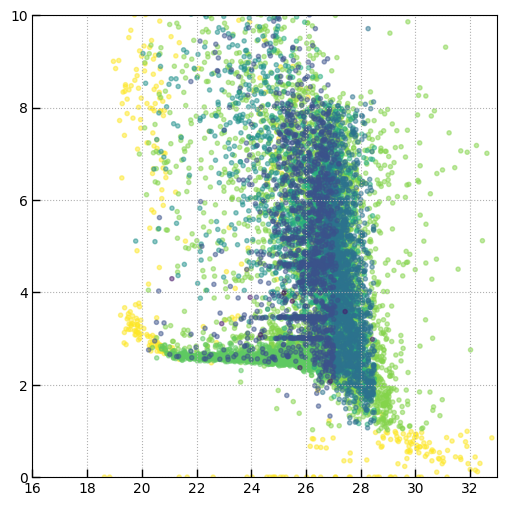

In [27]:
so = np.argsort(zout['priority'])[::-1]

plt.scatter(zout['F444W'][so], cat['flux_radius'][so], c=zout['priority'][so], alpha=0.5)
plt.ylim(0, 10)
plt.xlim(16, 33)

plt.grid()

   N  value     
====  ==========
   2           0
  11           1
1428           4
1360           6
 641           8
1511          10
1553          12
4401          13
 792          16


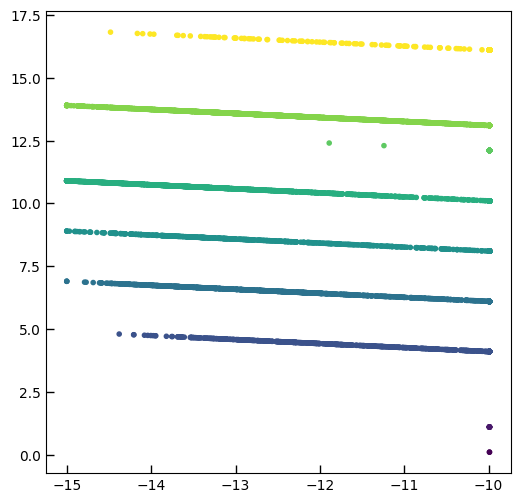

In [28]:
# Continuous weight in priority bins
minmax_weight = np.min(zout['weight']), np.max(zout['weight'])

p12 = zout['priority'] < 12
minmax_weight = np.min(zout['weight'][p12]), np.max(zout['weight'][p12])

zout['inv_weight'] = np.interp(zout['weight'], minmax_weight, [0.9,0.1])

zout['priority_weight'] = 0.
un = utils.Unique(zout['priority'])

for p in un.values:
    zout['priority_weight'][un[p]] = zout['inv_weight'][un[p]]+ p

zout['xweight'] = zout['priority_weight'].max() - zout['priority_weight']

plt.scatter(zout['weight'], zout['priority_weight'], c=zout['priority'])

In [29]:
nrs['Weight'] =    zout['xweight'] * 1.0
nrs['Priority'] =  zout['priority']

nrs['Weight'][nrs['Priority'] == 0] += 50000
nrs['Weight'][nrs['Priority'] == 1] += 5000
nrs['Weight'][nrs['Priority'] == 2] += 500
nrs['Weight'][nrs['Priority'] == 3] += 100

nrs

ID,RA,Dec,Magnitude,Redshift,Ellipticity,R50,NRS_F110W,NRS_F140X,NRS_CLEAR,Reference,Weight,Priority
,deg,deg,uJy,,,,uJy,,,,,
int32,float64,float64,float64,float32,float64,float64,float64,int64,int64,int64,float64,int64
1,289.2505037,-33.5452845,99.000,-1.0000,0.03,0.0,30.51,99.00,99.00,0,0.7171912135946741,16
2,289.2524870,-33.5450885,99.000,1.2989,0.18,0.5382724520324231,30.16,99.00,99.00,0,0.7171912135946741,16
3,289.2504920,-33.5450635,23.593,6.3323,0.07,2.588352526586479,22.50,99.00,99.00,0,4.717191213594676,12
4,289.2507441,-33.5448939,26.513,6.2054,0.03,2.3676482024616448,25.44,99.00,99.00,0,0.7171912135946741,16
5,289.2542902,-33.5448019,25.760,6.1787,0.50,7.035807284615698,24.50,99.00,99.00,0,12.717191213594676,4
6,289.2534218,-33.5447407,26.137,4.7680,0.55,6.997473508296797,28.60,99.00,99.00,0,12.29328113698845,4
7,289.2531409,-33.5448280,23.605,1.4195,0.42,8.206873046447052,24.59,99.00,99.00,0,8.384545425373098,8
8,289.2533440,-33.5447007,26.500,6.7926,0.52,7.006009214757325,26.77,99.00,99.00,0,12.419058468103927,4


## Trim catalog

In [30]:
trim = nrs['Priority'] >= 13
nrs = nrs[~trim]
cat = cat[~trim]
zout = zout[~trim]

## Match catalog reference position

Median of RA / Dec of a new catalog has to match that of the Phase 0 catalog,
so pad with dummy sources until it does

In [31]:
from astropy.coordinates import ICRS, SkyCoord
import astropy.table

def pad_catalog_median(nrs, cat_ref_str = '02:17:29.8978 -05:15:31.19', min_id=200000, priority=17., grow=1.1):
    """
    Add dummy objects to match the same median position of an APT catalog
    """

    ra = nrs['RA']
    dec = nrs['Dec']
    
    cat_ref = SkyCoord(cat_ref_str, unit=('hour','deg'), frame=ICRS)
    
    mra = np.median(ra)
    mde = np.median(dec)
    
    dra = mra - cat_ref.ra.deg
    dde = mde - cat_ref.dec.deg
    
    nra = (np.abs(ra - cat_ref.ra.deg) < np.abs(dra)).sum()
    nde = (np.abs(dec - cat_ref.dec.deg) < np.abs(dde)).sum()
    
    nadd = int(np.maximum(nra, nde)*grow)
    #nadd = int(np.maximum(nra, nde)*1.05)
    
    if ((len(ra)+nadd) % 1 == 0) & (nadd > 0):
        nadd += 1
        
    if nadd > 0:
        
        rix = np.zeros(nadd, dtype=int)
        ra = np.append(ra, np.ones(nadd)*cat_ref.ra.deg)
        dec = np.append(dec, np.ones(nadd)*cat_ref.dec.deg)
    
        cra = np.median(ra)
        cde = np.median(dec)
        
        cdra = cra - cat_ref.ra.deg
        cdde = cde - cat_ref.dec.deg
        
        print(f'Add {nadd} rows: median offset = {cdra:.4e} {cdde:.4e}')

        nfill = nrs[np.zeros(nadd, dtype=int)]
        nfill['ID'] = np.arange(nadd, dtype=nrs['ID'].dtype) + min_id
        nfill['RA'] = ra[-nadd:]
        nfill['Dec'] = dec[-nadd:]
        nfill['Priority'] = priority
        nfill['Weight'] = 0

        return nfill
    else:
        print('Catalog median matches target')
        
        return None
        
    if 0:
        so = np.argsort(dec)
        plt.plot(dec[so], np.cumsum(np.ones_like(dec)))
        plt.scatter(cat_ref.dec.deg, 0.5*dec.size, alpha=0.5)

In [32]:
nrs[nrs['Priority'] < 3.5]

ID,RA,Dec,Magnitude,Redshift,Ellipticity,R50,NRS_F110W,NRS_F140X,NRS_CLEAR,Reference,Weight,Priority
,deg,deg,uJy,,,,uJy,,,,,
int32,float64,float64,float64,float32,float64,float64,float64,int64,int64,int64,float64,int64
942,289.2709885,-33.5357147,22.918,7.0655,0.22,3.3224919616479673,27.52,99.00,99.00,0,5015.717191213595,1
1037,289.2805744,-33.5350208,28.427,17.3362,0.37,2.9831091704075923,28.47,99.00,99.00,0,5015.717191213595,1
1992,289.2807529,-33.5292045,23.957,3.4612,0.46,3.8916995995440105,26.94,99.00,99.00,0,5015.717191213595,1
2643,289.2887172,-33.5266428,21.454,4.2120,0.47,12.560941568334501,22.65,99.00,99.00,0,5015.717191213595,1
2690,289.2587767,-33.5256741,25.195,8.9429,0.40,3.9854391298028324,31.76,99.00,99.00,0,50016.7171912136,0
2691,289.2587625,-33.5256082,25.497,7.1492,0.16,3.8098590561575905,29.77,99.00,99.00,0,50016.7171912136,0
3060,289.2895736,-33.5240919,20.660,4.1692,0.70,18.421591183836856,21.86,99.00,99.00,0,5015.717191213595,1
3219,289.2689930,-33.5275649,23.323,1.5262,0.88,18.54413424933125,22.90,99.00,99.00,0,5015.717191213595,1


In [33]:
# Get MSA catalog reference coordinate from APT, here for GO-12581, PG004
cat_ref = '19:17:4.8100 -33:31:32.19'
suffix = 'v1_260529'

nfill = pad_catalog_median(nrs, cat_ref_str=cat_ref, grow=2, min_id=200000)

nfill['ID'] += 400000
nrs_fill = astropy.table.vstack([nrs, nfill])

apt_file = f"{prefix}_{suffix}.vot"
print(apt_file)

nrs_fill.write(apt_file, format='votable', overwrite=True)

Add 6507 rows: median offset = 0.0000e+00 0.0000e+00
VENUS/PG004/pg004_v1_260529.vot


# Done!  Import the VOT catalog just produced into `APT -> Targets -> MSA Catalogs`

- APT should automatically recognize all of the column names other than ``Priority``.  Manually indicate that one as a "Number" column if you want to use it for target subsets.
- Check that the `Reference position` of the imported catalog matches that of the preliminary catalog submitted with the proposal